## 1. Imports

In [89]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

## 2. Load Week 8 Customer Analytics

In [90]:
customer_analytics = pd.read_csv("../data/cleaned/customer_analytics.csv")
customer_segment_summary = pd.read_csv("../data/cleaned/customer_segment_summary.csv")

print("Customer Analytics:", customer_analytics.shape)
display(customer_analytics.head())

Customer Analytics: (500, 20)


,customer_id,customer_type,industry_segment,city,state,region,branch_id,recency,frequency,monetary,average_order_value,R_score,F_score,M_score,RFM_score,RFM_total,customer_segment,credit_limit,current_balance,customer_rating
0,C0153,Retail,Rental,Patna,Bihar,East,Pun001,19,59,"109,360,638.60","1,853,570.15",4,5,5,455,14,Champions,32014,27630,4
1,C0483,Corporate,Rental,Delhi,Delhi,North,Del001,13,53,"108,672,502.00","2,050,424.57",4,5,5,455,14,Champions,511858,312732,1
2,C0288,Dealer,Infrastructure,Delhi,Delhi,North,Del001,74,63,"107,119,652.20","1,700,311.94",2,5,5,255,12,Loyal Customers,279745,19656,3
3,C0495,Fleet Owner,Infrastructure,Jaipur,Rajasthan,North,Ahm001,36,52,"105,717,422.20","2,033,027.35",3,5,5,355,13,Champions,414484,135441,2
4,C0420,Retail,Rental,Chennai,Tamil Nadu,South,Chn001,39,54,"105,420,085.20","1,952,223.80",3,5,5,355,13,Champions,44758,199,3


## 3. Load Sales Data

In [91]:
sales_header = pd.read_csv("../data/cleaned/sales_header.csv")

sales_header["order_date"] = pd.to_datetime(sales_header["order_date"], errors="coerce")

print("Sales Header:", sales_header.shape)
display(sales_header.head())

Sales Header: (20000, 15)


,so_id,customer_id,branch_id,order_date,delivery_date,order_status,payment_terms,total_order_value,total_gst_amount,grand_total,sales_channel,order_date_year,order_date_month,delivery_date_year,delivery_date_month
0,So-990591,C0070,Ahm001,2022-05-24,2022-05-28,Delivered,Net 30,1345720,"374,439.60","1,720,159.60",Counter Sale,2022,5,2022,5
1,So-431510,C0031,Kol001,2022-05-01,2022-05-08,Delivered,Advance,2194850,"609,423.00","2,804,273.00",Dealer Network,2022,5,2022,5
2,So-495859,C0013,Ahm001,2023-10-01,2023-10-02,Delivered,Advance,2620800,"733,824.00","3,354,624.00",Online,2023,10,2023,10
3,So-745068,C0382,Hyd001,2021-10-04,2021-10-09,Delivered,Advance,1094950,"292,961.00","1,387,911.00",Online,2021,10,2021,10
4,So-175713,C0472,Chn001,2024-10-31,2024-11-04,Delivered,Net 45,1250,225.00,"1,475.00",Counter Sale,2024,10,2024,11


## 4. Dataset Overview

In [92]:
print("Customer analytics columns:")
print(customer_analytics.columns.tolist())

print("\nSales header columns:")
print(sales_header.columns.tolist())

print("\nMissing values:")
display(customer_analytics.isna().sum().sort_values(ascending=False).head(10))

Customer analytics columns:
['customer_id', 'customer_type', 'industry_segment', 'city', 'state', 'region', 'branch_id', 'recency', 'frequency', 'monetary', 'average_order_value', 'R_score', 'F_score', 'M_score', 'RFM_score', 'RFM_total', 'customer_segment', 'credit_limit', 'current_balance', 'customer_rating']

Sales header columns:
['so_id', 'customer_id', 'branch_id', 'order_date', 'delivery_date', 'order_status', 'payment_terms', 'total_order_value', 'total_gst_amount', 'grand_total', 'sales_channel', 'order_date_year', 'order_date_month', 'delivery_date_year', 'delivery_date_month']

Missing values:


customer_id         0
customer_type       0
industry_segment    0
city                0
state               0
region              0
branch_id           0
recency             0
frequency           0
monetary            0
dtype: int64

## 5. Prepare Customer Transaction Data

In [93]:
sales = sales_header.copy()

sales = sales.dropna(subset=["customer_id", "order_date"])

sales["customer_id"] = sales["customer_id"].astype(str)
sales["grand_total"] = pd.to_numeric(sales["grand_total"], errors="coerce").fillna(0)

print("Transactions:", len(sales))
print("Customers:", sales["customer_id"].nunique())

Transactions: 20000
Customers: 500


## 6. Calculate Customer Revenue Metrics

In [94]:
customer_revenue = (
    sales.groupby("customer_id")
    .agg(
        total_revenue=("grand_total", "sum"),
        total_orders=("so_id", "nunique"),
        average_order_value=("grand_total", "mean")
    )
    .reset_index()
)

display(customer_revenue.head())

,customer_id,total_revenue,total_orders,average_order_value
0,C0001,"67,052,288.00",40,"1,676,307.20"
1,C0002,"77,917,319.20",56,"1,391,380.70"
2,C0003,"50,921,823.20",40,"1,273,045.58"
3,C0004,"62,484,367.60",47,"1,329,454.63"
4,C0005,"85,668,379.80",51,"1,679,772.15"


## 7. Calculate Purchase Frequency

In [95]:
purchase_frequency = (
    sales.groupby("customer_id")
    .agg(
        first_purchase_date=("order_date", "min"),
        last_purchase_date=("order_date", "max"),
        purchase_frequency=("so_id", "nunique")
    )
    .reset_index()
)

purchase_frequency["customer_lifespan_days"] = (
    purchase_frequency["last_purchase_date"]
    - purchase_frequency["first_purchase_date"]
).dt.days

purchase_frequency["customer_lifespan_days"] = (
    purchase_frequency["customer_lifespan_days"].clip(lower=0)
)

display(purchase_frequency.head())

,customer_id,first_purchase_date,last_purchase_date,purchase_frequency,customer_lifespan_days
0,C0001,2019-01-26,2024-12-25,40,2160
1,C0002,2019-01-24,2024-11-28,56,2135
2,C0003,2019-04-05,2024-10-30,40,2035
3,C0004,2019-03-21,2024-12-31,47,2112
4,C0005,2019-02-28,2024-10-04,51,2045


## 8. Calculate Customer Lifespan

In [96]:
analysis_date = sales["order_date"].max()

purchase_frequency["recency_days"] = (
    analysis_date - purchase_frequency["last_purchase_date"]
).dt.days

purchase_frequency["customer_lifespan_years"] = (
    purchase_frequency["customer_lifespan_days"] / 365
)

display(
    purchase_frequency[
        ["customer_id", "first_purchase_date", "last_purchase_date",
         "customer_lifespan_days", "recency_days"]
    ].head()
)

,customer_id,first_purchase_date,last_purchase_date,customer_lifespan_days,recency_days
0,C0001,2019-01-26,2024-12-25,2160,6
1,C0002,2019-01-24,2024-11-28,2135,33
2,C0003,2019-04-05,2024-10-30,2035,62
3,C0004,2019-03-21,2024-12-31,2112,0
4,C0005,2019-02-28,2024-10-04,2045,88


## 9. Calculate Customer Lifetime Value

In [97]:
clv = customer_revenue.merge(
    purchase_frequency[[
        "customer_id",
        "customer_lifespan_days",
        "customer_lifespan_years",
        "recency_days"
    ]],
    on="customer_id",
    how="left"
)

# Historical CLV proxy based on observed customer revenue and purchase behaviour.
clv["annual_purchase_frequency"] = np.where(
    clv["customer_lifespan_years"] > 0,
    clv["total_orders"] / clv["customer_lifespan_years"],
    clv["total_orders"]
)

clv["estimated_clv"] = (
    clv["average_order_value"]
    * clv["annual_purchase_frequency"]
)

clv["estimated_clv"] = clv["estimated_clv"].replace(
    [np.inf, -np.inf], np.nan
).fillna(clv["total_revenue"])

display(clv.sort_values("estimated_clv", ascending=False).head(10))

,customer_id,total_revenue,total_orders,average_order_value,customer_lifespan_days,customer_lifespan_years,recency_days,annual_purchase_frequency,estimated_clv
287,C0288,"107,119,652.20",63,"1,700,311.94",2066,5.66,74,11.13,"18,924,817.55"
482,C0483,"108,672,502.00",53,"2,050,424.57",2128,5.83,13,9.09,"18,639,785.35"
152,C0153,"109,360,638.60",59,"1,853,570.15",2156,5.91,19,9.99,"18,514,208.30"
253,C0254,"96,361,380.00",52,"1,853,103.46",1913,5.24,97,9.92,"18,385,731.16"
341,C0342,"100,153,639.60",44,"2,276,219.08",2007,5.50,83,8.00,"18,214,289.21"
239,C0240,"104,286,776.80",50,"2,085,735.54",2091,5.73,51,8.73,"18,204,052.38"
419,C0420,"105,420,085.20",54,"1,952,223.80",2143,5.87,39,9.20,"17,955,357.49"
206,C0207,"101,737,768.40",51,"1,994,858.20",2072,5.68,79,8.98,"17,921,952.44"
494,C0495,"105,717,422.20",52,"2,033,027.35",2155,5.90,36,8.81,"17,905,735.08"
82,C0083,"94,364,155.40",50,"1,887,283.11",1961,5.37,88,9.31,"17,563,955.49"


## 10. Create CLV Segments

In [98]:
clv["clv_segment"] = pd.qcut(
    clv["estimated_clv"].rank(method="first"),
    q=4,
    labels=["Low CLV", "Medium CLV", "High CLV", "Very High CLV"]
)

clv_summary = (
    clv.groupby("clv_segment", observed=False)
    .agg(
        customers=("customer_id", "nunique"),
        total_clv=("estimated_clv", "sum"),
        average_clv=("estimated_clv", "mean"),
        revenue=("total_revenue", "sum")
    )
    .reset_index()
)

display(clv_summary)

,clv_segment,customers,total_clv,average_clv,revenue
0,Low CLV,125,"1,070,644,506.63","8,565,156.05","6,101,794,745.00"
1,Medium CLV,125,"1,291,862,920.20","10,334,903.36","7,382,645,209.20"
2,High CLV,125,"1,495,822,155.02","11,966,577.24","8,547,012,663.00"
3,Very High CLV,125,"1,829,191,092.32","14,633,528.74","10,393,301,938.60"


## 11. Calculate Churn Indicators

In [99]:
# Churn is represented here as a risk indicator based on recency.
# Thresholds are analytical rules and are not a confirmed churn outcome.

clv["churn_risk"] = pd.cut(
    clv["recency_days"],
    bins=[-1, 30, 60, 90, np.inf],
    labels=["Low Risk", "Moderate Risk", "High Risk", "Very High Risk"]
)

display(
    clv[[
        "customer_id", "recency_days", "total_revenue",
        "estimated_clv", "churn_risk"
    ]].head(10)
)

,customer_id,recency_days,total_revenue,estimated_clv,churn_risk
0,C0001,6,"67,052,288.00","11,330,594.96",Low Risk
1,C0002,33,"77,917,319.20","13,320,759.49",Moderate Risk
2,C0003,62,"50,921,823.20","9,133,398.26",High Risk
3,C0004,0,"62,484,367.60","10,798,671.48",Low Risk
4,C0005,88,"85,668,379.80","15,290,444.32",High Risk
5,C0006,120,"77,685,503.40","14,459,565.91",Very High Risk
6,C0007,58,"48,267,553.20","8,782,481.02",Moderate Risk
7,C0008,168,"49,133,801.00","9,145,251.08",Very High Risk
8,C0009,57,"68,836,324.80","12,370,880.63",Moderate Risk
9,C0010,34,"69,405,822.80","11,865,632.47",Moderate Risk


## 12. Create Customer Risk Scores

In [100]:
# Customer Risk Scoring

# Create customer risk dataframe from customer analytics
customer_risk = customer_analytics.copy()

# Rename existing RFM fields for predictive analysis
customer_risk["recency_days"] = customer_risk["recency"]
customer_risk["purchase_frequency"] = customer_risk["frequency"]

# Calculate estimated CLV
customer_risk["estimated_clv"] = (
    customer_risk["average_order_value"] *
    customer_risk["purchase_frequency"]
)

# Recency risk
customer_risk["recency_risk"] = pd.cut(
    customer_risk["recency_days"],
    bins=[-1, 30, 60, 90, float("inf")],
    labels=[0, 1, 2, 3]
).astype(int)

# Purchase frequency risk
customer_risk["frequency_risk"] = np.select(
    [
        customer_risk["purchase_frequency"] >= 12,
        customer_risk["purchase_frequency"] >= 6,
        customer_risk["purchase_frequency"] >= 3
    ],
    [0, 1, 2],
    default=3
)

# Customer value risk
customer_risk["value_risk"] = pd.qcut(
    customer_risk["estimated_clv"].rank(method="first"),
    q=4,
    labels=[3, 2, 1, 0]
).astype(int)

# Total risk score
customer_risk["customer_risk_score"] = (
    customer_risk["recency_risk"]
    + customer_risk["frequency_risk"]
    + customer_risk["value_risk"]
)

# Risk level
customer_risk["risk_level"] = pd.cut(
    customer_risk["customer_risk_score"],
    bins=[-1, 2, 4, 6, float("inf")],
    labels=[
        "Low Risk",
        "Moderate Risk",
        "High Risk",
        "Very High Risk"
    ]
)

customer_risk.head()

,customer_id,customer_type,industry_segment,city,state,region,branch_id,recency,frequency,monetary,average_order_value,R_score,F_score,M_score,RFM_score,RFM_total,customer_segment,credit_limit,current_balance,customer_rating,recency_days,purchase_frequency,estimated_clv,recency_risk,frequency_risk,value_risk,customer_risk_score,risk_level
0,C0153,Retail,Rental,Patna,Bihar,East,Pun001,19,59,"109,360,638.60","1,853,570.15",4,5,5,455,14,Champions,32014,27630,4,19,59,"109,360,638.60",0,0,0,0,Low Risk
1,C0483,Corporate,Rental,Delhi,Delhi,North,Del001,13,53,"108,672,502.00","2,050,424.57",4,5,5,455,14,Champions,511858,312732,1,13,53,"108,672,502.00",0,0,0,0,Low Risk
2,C0288,Dealer,Infrastructure,Delhi,Delhi,North,Del001,74,63,"107,119,652.20","1,700,311.94",2,5,5,255,12,Loyal Customers,279745,19656,3,74,63,"107,119,652.20",2,0,0,2,Low Risk
3,C0495,Fleet Owner,Infrastructure,Jaipur,Rajasthan,North,Ahm001,36,52,"105,717,422.20","2,033,027.35",3,5,5,355,13,Champions,414484,135441,2,36,52,"105,717,422.20",1,0,0,1,Low Risk
4,C0420,Retail,Rental,Chennai,Tamil Nadu,South,Chn001,39,54,"105,420,085.20","1,952,223.80",3,5,5,355,13,Champions,44758,199,3,39,54,"105,420,085.20",1,0,0,1,Low Risk


## 13. Customer Churn/Risk Segmentation

In [101]:
# Customer Risk Summary

risk_summary = (
    customer_risk.groupby("risk_level", observed=False)
    .agg(
        customers=("customer_id", "nunique"),
        total_clv=("estimated_clv", "sum"),
        average_clv=("estimated_clv", "mean"),
        average_risk_score=("customer_risk_score", "mean")
    )
    .reset_index()
)

risk_summary

,risk_level,customers,total_clv,average_clv,average_risk_score
0,Low Risk,250,"18,222,109,362.00","72,888,437.45",1.26
1,Moderate Risk,177,"10,465,156,755.80","59,125,179.41",3.44
2,High Risk,73,"3,737,488,438.00","51,198,471.75",5.48
3,Very High Risk,0,0.00,NaN,NaN


## 14. Analyze High-Value Customers at Risk

In [102]:
# Create customer risk levels

# Make sure total risk score exists
customer_risk["customer_risk_score"] = (
    customer_risk["recency_risk"]
    + customer_risk["frequency_risk"]
    + customer_risk["value_risk"]
)

# Create risk level
customer_risk["risk_level"] = pd.cut(
    customer_risk["customer_risk_score"],
    bins=[-1, 2, 4, 6, float("inf")],
    labels=[
        "Low Risk",
        "Moderate Risk",
        "High Risk",
        "Very High Risk"
    ],
    include_lowest=True
)

# Check result
customer_risk[
    ["customer_id", "customer_risk_score", "risk_level"]
].head()

,customer_id,customer_risk_score,risk_level
0,C0153,0,Low Risk
1,C0483,0,Low Risk
2,C0288,2,Low Risk
3,C0495,1,Low Risk
4,C0420,1,Low Risk


## 15. Analyze Retention Opportunities

In [103]:
# Retention Opportunities

retention_opportunities = customer_risk[
    customer_risk["risk_level"].isin(["High Risk", "Very High Risk"])
].copy()

# Assign retention priority based on customer value
retention_opportunities["retention_priority"] = np.select(
    [
        retention_opportunities["risk_level"].eq("Very High Risk") &
        retention_opportunities["estimated_clv"].ge(
            retention_opportunities["estimated_clv"].quantile(0.75)
        ),
        retention_opportunities["estimated_clv"].ge(
            retention_opportunities["estimated_clv"].quantile(0.50)
        )
    ],
    ["Critical", "High"],
    default="Medium"
)

retention_opportunities.head()

,customer_id,customer_type,industry_segment,city,state,region,branch_id,recency,frequency,monetary,average_order_value,R_score,F_score,M_score,RFM_score,RFM_total,customer_segment,credit_limit,current_balance,customer_rating,recency_days,purchase_frequency,estimated_clv,recency_risk,frequency_risk,value_risk,customer_risk_score,risk_level,retention_priority
253,C0256,Corporate,Infrastructure,Guwahati,Assam,North East,Pun001,103,34,"63,561,255.00","1,869,448.68",1,1,3,113,5,At Risk,930018,60762,4,103,34,"63,561,255.00",3,0,2,5,High Risk,High
261,C0419,Fleet Owner,Logistics,Mumbai,Maharashtra,West,Ahm001,92,34,"63,139,736.80","1,857,051.08",1,1,3,113,5,At Risk,344338,246613,1,92,34,"63,139,736.80",3,0,2,5,High Risk,High
270,C0024,Dealer,Rental,Visakhapatnam,Andhra Pradesh,South,Chn001,105,48,"62,453,301.20","1,301,110.44",1,5,3,153,9,Potential Customers,266822,86814,4,105,48,"62,453,301.20",3,0,2,5,High Risk,High
273,C0450,Fleet Owner,Construction,Kolkata,West Bengal,East,Kol001,110,43,"62,233,287.40","1,447,285.75",1,4,3,143,8,Potential Customers,139226,122462,5,110,43,"62,233,287.40",3,0,2,5,High Risk,High
276,C0158,Corporate,Infrastructure,Kolkata,West Bengal,East,Kol001,96,37,"62,074,622.20","1,677,692.49",1,2,3,123,6,At Risk,516521,146194,2,96,37,"62,074,622.20",3,0,2,5,High Risk,High


## 16. Industry, Region and Branch Risk Analysis

In [104]:
# Customer details with risk analysis

customer_details = customer_analytics.copy()

customer_details["customer_id"] = customer_details["customer_id"].astype(str)
customer_risk["customer_id"] = customer_risk["customer_id"].astype(str)

risk_with_details = customer_risk.merge(
    customer_details,
    on="customer_id",
    how="left",
    suffixes=("", "_details")
)

risk_with_details.head()

,customer_id,customer_type,industry_segment,city,state,region,branch_id,recency,frequency,monetary,average_order_value,R_score,F_score,M_score,RFM_score,RFM_total,customer_segment,credit_limit,current_balance,customer_rating,recency_days,purchase_frequency,estimated_clv,recency_risk,frequency_risk,value_risk,customer_risk_score,risk_level,customer_type_details,industry_segment_details,city_details,state_details,region_details,branch_id_details,recency_details,frequency_details,monetary_details,average_order_value_details,R_score_details,F_score_details,M_score_details,RFM_score_details,RFM_total_details,customer_segment_details,credit_limit_details,current_balance_details,customer_rating_details
0,C0153,Retail,Rental,Patna,Bihar,East,Pun001,19,59,"109,360,638.60","1,853,570.15",4,5,5,455,14,Champions,32014,27630,4,19,59,"109,360,638.60",0,0,0,0,Low Risk,Retail,Rental,Patna,Bihar,East,Pun001,19,59,"109,360,638.60","1,853,570.15",4,5,5,455,14,Champions,32014,27630,4
1,C0483,Corporate,Rental,Delhi,Delhi,North,Del001,13,53,"108,672,502.00","2,050,424.57",4,5,5,455,14,Champions,511858,312732,1,13,53,"108,672,502.00",0,0,0,0,Low Risk,Corporate,Rental,Delhi,Delhi,North,Del001,13,53,"108,672,502.00","2,050,424.57",4,5,5,455,14,Champions,511858,312732,1
2,C0288,Dealer,Infrastructure,Delhi,Delhi,North,Del001,74,63,"107,119,652.20","1,700,311.94",2,5,5,255,12,Loyal Customers,279745,19656,3,74,63,"107,119,652.20",2,0,0,2,Low Risk,Dealer,Infrastructure,Delhi,Delhi,North,Del001,74,63,"107,119,652.20","1,700,311.94",2,5,5,255,12,Loyal Customers,279745,19656,3
3,C0495,Fleet Owner,Infrastructure,Jaipur,Rajasthan,North,Ahm001,36,52,"105,717,422.20","2,033,027.35",3,5,5,355,13,Champions,414484,135441,2,36,52,"105,717,422.20",1,0,0,1,Low Risk,Fleet Owner,Infrastructure,Jaipur,Rajasthan,North,Ahm001,36,52,"105,717,422.20","2,033,027.35",3,5,5,355,13,Champions,414484,135441,2
4,C0420,Retail,Rental,Chennai,Tamil Nadu,South,Chn001,39,54,"105,420,085.20","1,952,223.80",3,5,5,355,13,Champions,44758,199,3,39,54,"105,420,085.20",1,0,0,1,Low Risk,Retail,Rental,Chennai,Tamil Nadu,South,Chn001,39,54,"105,420,085.20","1,952,223.80",3,5,5,355,13,Champions,44758,199,3


## 17. Customer Value Visualization

<Figure size 800x500 with 0 Axes>

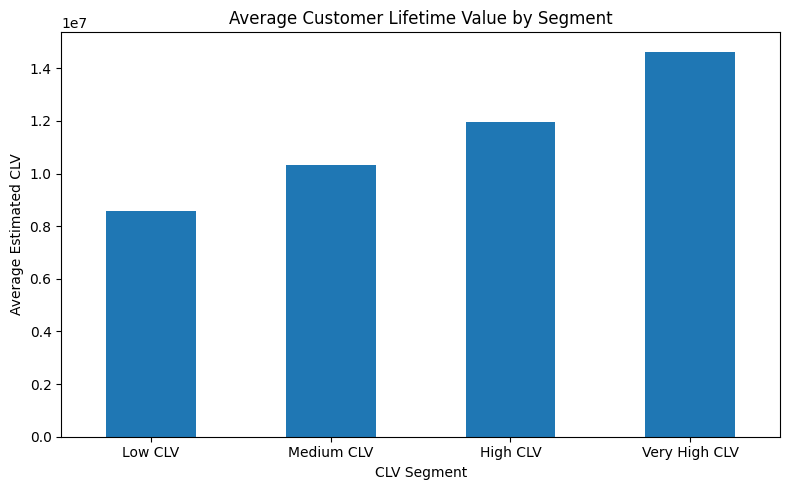

In [105]:
plt.figure(figsize=(8, 5))
clv_summary.plot(
    x="clv_segment",
    y="average_clv",
    kind="bar",
    legend=False,
    figsize=(8, 5)
)
plt.title("Average Customer Lifetime Value by Segment")
plt.xlabel("CLV Segment")
plt.ylabel("Average Estimated CLV")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 18. Churn/Risk Visualization

In [106]:
# Customer Risk Distribution

risk_counts = (
    customer_risk["risk_level"]
    .value_counts()
    .reindex(
        ["Low Risk", "Moderate Risk", "High Risk", "Very High Risk"]
    )
    .fillna(0)
    .astype(int)
)

risk_counts

risk_level
Low Risk          250
Moderate Risk     177
High Risk          73
Very High Risk      0
Name: count, dtype: int64

## 19. Predictive KPI Dashboard

In [107]:
# Predictive Customer KPI Dashboard

total_customers = customer_risk["customer_id"].nunique()
total_estimated_clv = customer_risk["estimated_clv"].sum()
average_estimated_clv = customer_risk["estimated_clv"].mean()

high_risk_customers = customer_risk[
    customer_risk["risk_level"].isin(["High Risk", "Very High Risk"])
]["customer_id"].nunique()

high_value_at_risk = customer_risk[
    customer_risk["estimated_clv"].ge(
        customer_risk["estimated_clv"].quantile(0.75)
    )
    & customer_risk["risk_level"].isin(["High Risk", "Very High Risk"])
]["customer_id"].nunique()

high_risk_clv = customer_risk[
    customer_risk["risk_level"].isin(["High Risk", "Very High Risk"])
]["estimated_clv"].sum()

kpi_dashboard = pd.DataFrame({
    "KPI": [
        "Total Customers",
        "Total Estimated CLV",
        "Average Estimated CLV",
        "High/Very High Risk Customers",
        "High-Value Customers at Risk",
        "Estimated CLV of High-Risk Customers"
    ],
    "Value": [
        total_customers,
        total_estimated_clv,
        average_estimated_clv,
        high_risk_customers,
        high_value_at_risk,
        high_risk_clv
    ]
})

kpi_dashboard

,KPI,Value
0,Total Customers,500.00
1,Total Estimated CLV,"32,424,754,555.80"
2,Average Estimated CLV,"64,849,509.11"
3,High/Very High Risk Customers,73.00
4,High-Value Customers at Risk,0.00
5,Estimated CLV of High-Risk Customers,"3,737,488,438.00"


## 20. Final Insights, Recommendations and Validation

In [108]:
# Predictive Customer KPI Dashboard

# Make sure estimated CLV exists
if "estimated_clv" not in customer_risk.columns:
    customer_risk["estimated_clv"] = (
        customer_risk["average_order_value"]
        * customer_risk["frequency"]
    )

# Make sure risk level exists
if "risk_level" not in customer_risk.columns:

    customer_risk["recency_risk"] = pd.cut(
        customer_risk["recency"],
        bins=[-1, 30, 60, 90, float("inf")],
        labels=[0, 1, 2, 3]
    ).astype(int)

    customer_risk["frequency_risk"] = np.select(
        [
            customer_risk["frequency"] >= 12,
            customer_risk["frequency"] >= 6,
            customer_risk["frequency"] >= 3
        ],
        [0, 1, 2],
        default=3
    )

    customer_risk["value_risk"] = pd.qcut(
        customer_risk["estimated_clv"].rank(method="first"),
        q=4,
        labels=[3, 2, 1, 0]
    ).astype(int)

    customer_risk["customer_risk_score"] = (
        customer_risk["recency_risk"]
        + customer_risk["frequency_risk"]
        + customer_risk["value_risk"]
    )

    customer_risk["risk_level"] = pd.cut(
        customer_risk["customer_risk_score"],
        bins=[-1, 2, 4, 6, float("inf")],
        labels=[
            "Low Risk",
            "Moderate Risk",
            "High Risk",
            "Very High Risk"
        ]
    )

# KPI calculations
total_customers = customer_risk["customer_id"].nunique()

total_estimated_clv = customer_risk["estimated_clv"].sum()

average_estimated_clv = customer_risk["estimated_clv"].mean()

high_risk_customers = customer_risk[
    customer_risk["risk_level"].isin(
        ["High Risk", "Very High Risk"]
    )
]["customer_id"].nunique()

high_value_at_risk = customer_risk[
    customer_risk["estimated_clv"].ge(
        customer_risk["estimated_clv"].quantile(0.75)
    )
    & customer_risk["risk_level"].isin(
        ["High Risk", "Very High Risk"]
    )
]["customer_id"].nunique()

high_risk_clv = customer_risk[
    customer_risk["risk_level"].isin(
        ["High Risk", "Very High Risk"]
    )
]["estimated_clv"].sum()

# Create KPI dashboard
kpi_dashboard = pd.DataFrame({
    "KPI": [
        "Total Customers",
        "Total Estimated CLV",
        "Average Estimated CLV",
        "High/Very High Risk Customers",
        "High-Value Customers at Risk",
        "Estimated CLV of High-Risk Customers"
    ],
    "Value": [
        total_customers,
        total_estimated_clv,
        average_estimated_clv,
        high_risk_customers,
        high_value_at_risk,
        high_risk_clv
    ]
})

kpi_dashboard

,KPI,Value
0,Total Customers,500.00
1,Total Estimated CLV,"32,424,754,555.80"
2,Average Estimated CLV,"64,849,509.11"
3,High/Very High Risk Customers,73.00
4,High-Value Customers at Risk,0.00
5,Estimated CLV of High-Risk Customers,"3,737,488,438.00"
